# PCA Coursework Template

**Module:** COMP2870 Theoretical Foundations of Computer Science II

**Assignment:** PCA & Data Exploration using Gram–Schmidt QR

**Instructions:** Follow each task in order. Do not change the names or signatures of the three functions that are autograded**: `normalise_dataset`, `covariance`, and `sorted_eigenvalues`. You may add helper functions/cells as needed.

> Use only your own implementations (and the provided `solvers.py`) for PCA—do not call `numpy.linalg.eig` / `numpy.linalg.eigh` / `sklearn` for eigen computations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import solvers

## Important: solvers.py Interface

The provided `solvers.gram_schmidt_eigen` function has the following interface:

```python
solvers.gram_schmidt_eigen(A, max_iterations=1000, tolerance=1e-10)
```

**Parameters:**
- `A`: Symmetric square matrix of shape (n, n)
- `max_iterations`: Maximum number of QR iterations (default: 1000)
- `tolerance`: Convergence threshold (default: 1e-10)

**Returns:**
- `eigenvalues`: 1D numpy array of length n (**unsorted**)
- `eigenvectors`: 2D numpy array of shape (n, n) where `eigenvectors[:, i]` is the eigenvector corresponding to `eigenvalues[i]`

## 1. Load and prepare data

You will be given three options (boardgames / spotify / coffee). Point `DATASET_PATH` at **one** of them.

In [2]:
# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# Set the path to the dataset you are using.
# Examples: 'boardgame_data.csv', 'spotify.csv', 'coffee.csv'
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
DATASET_PATH = 'spotify_data.csv'  # change as needed

# Load
df = pd.read_csv(DATASET_PATH)
print("Loaded:", DATASET_PATH)
display(df.head())
print(df.info())

Loaded: spotify_data.csv


,track_name,track_album_release_date,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity
0,(What A) Wonderful World - Remastered,1960,0.524,0.543,-9.889,0.0397,0.734,0.000000,0.2750,0.877,128.091,125507,13
1,Jingle Bells,1960,0.688,0.700,-6.295,0.0757,0.730,0.000000,0.7270,0.876,119.117,142547,11
2,At Last - Single Version,1960,0.168,0.326,-9.981,0.0324,0.721,0.000600,0.3160,0.322,174.794,182400,25
3,Green Onions,1962,0.816,0.514,-8.741,0.0339,0.767,0.949000,0.0899,0.912,136.837,176333,64
4,Christmas (Baby Please Come Home),1963,0.343,0.760,-7.146,0.0513,0.392,0.000388,0.0773,0.356,126.322,166453,73


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1327 entries, 0 to 1326
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_name                1326 non-null   object 
 1   track_album_release_date  1327 non-null   int64  
 2   danceability              1327 non-null   float64
 3   energy                    1327 non-null   float64
 4   loudness                  1327 non-null   float64
 5   speechiness               1327 non-null   float64
 6   acousticness              1327 non-null   float64
 7   instrumentalness          1327 non-null   float64
 8   liveness                  1327 non-null   float64
 9   valence                   1327 non-null   float64
 10  tempo                     1327 non-null   float64
 11  duration_ms               1327 non-null   int64  
 12  track_popularity          1327 non-null   int64  
dtypes: float64(9), int64(3), object(1)
memory usage: 134.9+ KB
None

Create a DataFrame `numeric_df` with only numeric columns. Decide and document how you handle missing values (e.g., drop rows with any NaNs).

In [3]:
# Select numeric columns
numeric_df = df.select_dtypes(include=[np.number]).copy()
n_sample_points, n_attributes = numeric_df.shape

print("Numeric shape:", numeric_df.shape)
display(numeric_df.head())

Numeric shape: (1327, 12)


,track_album_release_date,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,track_popularity
0,1960,0.524,0.543,-9.889,0.0397,0.734,0.000000,0.2750,0.877,128.091,125507,13
1,1960,0.688,0.700,-6.295,0.0757,0.730,0.000000,0.7270,0.876,119.117,142547,11
2,1960,0.168,0.326,-9.981,0.0324,0.721,0.000600,0.3160,0.322,174.794,182400,25
3,1962,0.816,0.514,-8.741,0.0339,0.767,0.949000,0.0899,0.912,136.837,176333,64
4,1963,0.343,0.760,-7.146,0.0513,0.392,0.000388,0.0773,0.356,126.322,166453,73


## 2. Visualise data

Plot histograms for all numeric columns.
Briefly comment on any skewness, multi-modality, or outliers you observe.

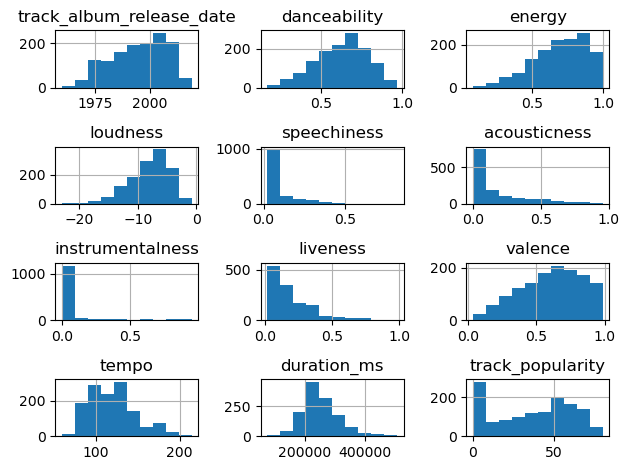

In [4]:
numeric_df.hist()
plt.tight_layout()

### Commentary

_TODO Write your observations on the histograms here. Suggested word limit: 50 words_

More tracks are released as time passes, so track album release skews to the right. Most tend to songs tend to group around 0.75 such as danceability, valence, loundess and energy. Meaning they all skew right. Acousticness, speechiness, instrumentalness, and livenesss all tend to group quite low, with many have a small amount of songs being more the 0. There is also a significant amount of tracks that people dislike, but popularity steadily rises after that. 

## 3. Write a function to normalise the dataset

Implement: `normalise_dataset` (autograded)

Standardise attributes to zero mean and unit variance. Return the normalised array and the per-attributes mean and std. Do not change the function name or signature.

In [5]:
def normalise_dataset(X):
    """
    Standardise the dataset attribute-wise to zero mean and unit variance.

    Parameters
    ----------
    X : np.ndarray
        2D array of shape (n_sample_points, n_attributes).

    Returns
    -------
    X_norm : np.ndarray
        Normalised data with zero mean and unit variance per attribute.
        Shape: (n_sample_points, n_attributes).
    mu : np.ndarray
        Attribute means. Shape: (n_attributes,).
    sigma : np.ndarray
        Attribute standard deviations. Shape: (n_attributes,).

    Notes
    -----
    * Compute mu as the mean of each column
    * Compute sigma as the standard deviation along each column
    * For attributes where sigma == 0 (constant attributes), set the normalized
      values to zero.
    * Do not use external ML libraries (sklearn, etc.).
    """
    # TODO: implement
 
    #mean = sum(values) / total n
    #sd = square root ( sum ((x i - mean))2 / total n)
    #normalise = x i - mean / sd

    #defining stuff
    n_sample_points, n_attributes = X.shape
    mu = np.zeros([n_attributes])
    sigma = np.zeros([n_attributes])
    X_norm = np.empty_like(X)

    for i in range(0, n_attributes):
        mu_total = 0 
        for j in range(0, n_sample_points):
            #adds up every value in the column
            mu_total = mu_total + X[j, i]
        mean = mu_total / n_sample_points
        #work out the variance, by iterating through every value in the column, (Value - mean) squared. Add all them up. then divide by n-1
        var = (sum((X[k, i] - mean)**2  for k in range(n_sample_points))) / (n_sample_points-1)
        #this uses the sample variance, because the data we have doesn't represent every song used in the world, its just a sample of them. 
        #raise to power of 1/2 so square root 
        sd = var ** 0.5
        #save mean in the mean array, and sd in the sigma array
        mu[i] = mean
        sigma[i] = sd
        for j in range(0, n_sample_points):
            if (sd == 0):
                #if var = 0, set value to 0
                X_norm[j, i] = 0
            else:
                #normalise using Xi - mu / sigma
                X_norm[j, i] = (X[j, i] - mean) / sd

    return X_norm, mu, sigma


#X = np.array([[1, 0], [3, 4], [5, 8]])
#X_norm, m, s = normalise_dataset(X)
#Y, mu, sigma = normalise_dataset = normalise_dataset(X_norm)
#print(X_norm)
#print(mu)
#print(sigma)

#X_norm, mu1, sigma1 = normalise_dataset(pd.DataFrame.to_numpy(numeric_df))
#Y_norm, mu2, sigma2 = normalise_dataset(X_norm)

#print(X_norm)
#print(mu2)
#print(sigma2)

## 4. Covariance analysis

Implement the `covariance` function and visualise the covariance matrix. Comment on any strong positive/negative relationships.

In [6]:
def covariance(X: np.ndarray) -> np.ndarray:
    """
    Compute the sample covariance matrix. You should not assume that the data is normalised in this function.

    Parameters
    ----------
    X : np.ndarray
        2D array of shape (n_sample_points, n_attributes).

    Returns
    -------
    np.ndarray
        Covariance matrix of shape (n_attributes, n_attributes).
        Element (i, j) represents the covariance between attributes i and j.

    Notes
    -----
    * The resulting matrix should be symmetric: C[i,j] == C[j,i].
    * Do not use numpy.cov() or other pre-built covariance functions.
    """

    X_norm, mu, sigma = normalise_dataset(X)
    #print(mu)
    n, m = X.shape
    #print(n)
    #print(m)
    C = np.zeros([m,m])

    #1/n-1 x sum of (Xki- mui) (Xkj-muj)


    for i in range(0, m):
        for j in range(0, m):
            #implements fomula. and changes C. k from 0 to n. 
            C[i, j] = sum((X[k, i] - mu[i])*(X[k, j] - mu[j]) for k in range(0, n)) / (n-1)

    return C
#X = np.array([[1, 0], [3, 4], [5, 8]])
#covariance(X)

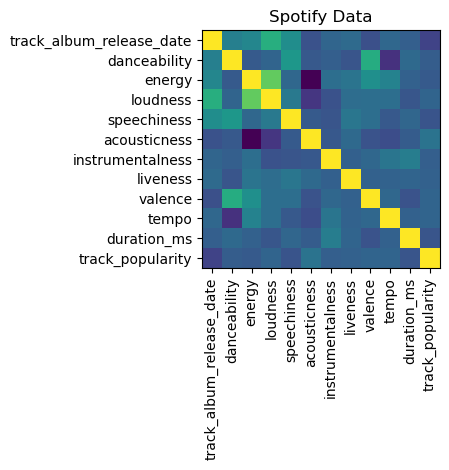

In [7]:
# Prepare a numpy array for covariance / PCA
X = numeric_df.values.astype(float)

# Compute covariance
X_std, _, _ = normalise_dataset(X)
C = covariance(X_std)

# Visualise covariance as a heatmap
# TODO implement
# HINT https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html

titles = ["track_album_release_date", "danceability", "energy", "loudness", "speechiness", "acousticness", "instrumentalness", "liveness", "valence","tempo","duration_ms", "track_popularity"]
fig, ax = plt.subplots()
im = ax.imshow(C)
ax.grid(which="minor", color="w", linestyle='-', linewidth=3)

ax.set_title("Spotify Data")
ax.set_xticks(range(len(titles)))
ax.set_yticks(range(len(titles)))
ax.set_xticklabels(titles, rotation=90)
ax.set_yticklabels(titles)
fig.tight_layout()
plt.show()

### Commentary
_TODO Interpret the covariance heatmap. Which attributes co-vary strongly? Any surprising patterns? Suggested word limit: 50 words_

The brighter colours mean a higher correlations betweeen the different aspects of a track. Of course the diagonal is the brightest, as you are comparing each section against itself and therefore they are the same. One surprising patter is that the track released date correlates quite strongly to loudness. And that the loudness correlates to valence. An expected one is that loudness correlates highly to energy. And acousticness and energy and negatively correlated. 

## 5. Eigenvalues and eigenvectors computations

Compute the eigenvalues and eigenvectors using the Gram–Schmidt QR method (from `solvers.py`)
Implement `sorted_eigenvalues` to (a) compute eigenpairs using `solvers.gram_schmidt_eigen`, and (b) sort them by **decreasing eigenvalue**.

In [8]:
def sorted_eigenvalues(A):
    """
    Compute eigenvalues and eigenvectors of A using the Gram–Schmidt QR
    algorithm, then sort them by decreasing eigenvalue.

    Parameters
    ----------
    A : np.ndarray
        A symmetric square matrix of shape (n, n).
        Typically this will be a covariance matrix.

    Returns
    -------
    eigenvalues : np.ndarray
        1D array of length n containing eigenvalues sorted in descending order.
    eigenvectors : np.ndarray
        2D array of shape (n, n) where column i (eigenvectors[:, i]) is the
        normalized eigenvector corresponding to eigenvalues[i].
        Eigenvectors are sorted to match the order of eigenvalues.

    Notes
    -----
    * Use solvers.gram_schmidt_eigen(A) to compute the eigendecomposition.
      This function returns (eigenvalues, eigenvectors, iterations).
      You only need the first two return values.
    * The function MODIFIES the input matrix A in place, so always pass A.copy().
    * The returned eigenvalues and eigenvectors are UNSORTED.
    * Sort the eigenvalues in descending order (largest first).
    * Reorder the eigenvector columns to match the sorted eigenvalue order.
    * Do not use numpy.linalg.eig, numpy.linalg.eigh, or similar functions.

    Example
    -------
    If A has eigenvalues [2.5, 5.1, 1.3], this function should return:
        eigenvalues = [5.1, 2.5, 1.3]
        eigenvectors[:, 0] corresponds to eigenvalue 5.1
        eigenvectors[:, 1] corresponds to eigenvalue 2.5
        eigenvectors[:, 2] corresponds to eigenvalue 1.3
    """
    
    eigenvalues, eigenvectors, iterations = solvers.gram_schmidt_eigen(A.copy())
    n = len(eigenvalues)

    #can sort using bubble sort
    for i in range(0, n-1):
        swapped_values = False
        for j in range(0, n-i-1):
            if (eigenvalues[i] < eigenvalues[i+1]):
                #if the eigenvalues swap, we also want to swap the eigen vectors rows
                temp = eigenvalues[i]
                eigenvalues[i] = eigenvalues[i+1]
                eigenvalues[i+1] = temp

                #swap the eigenvectors
                temp_vec = eigenvectors[:, i]
                eigenvectors[:, i] = eigenvectors[:, i+1]
                eigenvectors[:, i+1] = eigenvectors[:, i]

                #set this to true
                swapped_values = True

        if not swapped_values:
            break


    return eigenvalues, eigenvectors


In [9]:
# TODO Compute eigenvalues and eigenvectors of covariance and print first 5 eigenvalues
eigenvalues, eigenvectors = sorted_eigenvalues(C)



for i in range(0, 5):
    print(eigenvalues[i])

2.251319760320998
1.657111786613386
1.3567204002624542
1.2623465890691787
1.0128047917377008


## 6. Check orthonormality

Verify that the matrix of eigenvectors, $S$, satisfies $S^T S \approx I_n$. Report the maximum absolute deviation from the identity.

In [10]:
# TODO implement test of orthonormality
#they must be orthanormal to prove that each part is independent. They don't affect eachother. 
#transpose array

eigenvectors_T = eigenvectors.transpose()

new = eigenvectors_T @ eigenvectors
n, m = new.shape

#to check, can check that diagonals are ~ 1
#and check that the rest are near 0, doesnt have to be exact. I'm not really sure how exact they should be tbh. 
for i in range(0, n):
    if (new[i, i] - 1) < 0.001:
        for j in range(m):
            if (i==j):
                continue
            if (new[i, j] < 0.001 and new[i, j] > -0.001):
                continue
            else:
                print("not identity")
                break
    else: 
        print("It is infact not approx identity")
        break


## 7. Explained variance

Plot the variance explained by each principal component and the cumulative curve. Comment on how many components capture most variance.

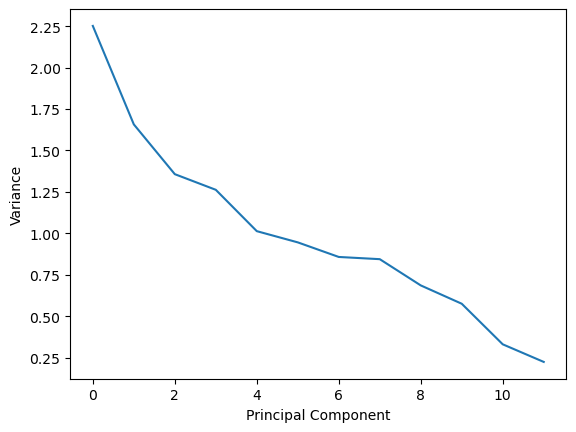

In [11]:
# TODO plot of cummulative explained variance

#plot each sections variance. Like the points along the bottom are the headings, then up the side is variance. 
#print(eigenvalues)

num_eigen_values = len(eigenvalues)

plt.plot(eigenvalues)
plt.ylabel("Variance")
plt.xlabel("Principal Component")
plt.show()


### Commentary
_TODO How many components would you retain and why? Suggested word limit: 50 words._

The fewer components there are, the higher the variance between them. The variance steadily decreases as the principal components increase. There is no point where you wouldn't be losing significant data. When you have the first 10 components, you retain about 90% of the data, and that could still give you strong correlations. However, this shows that each component of the music is important in comparing tracks against eachother. 

## 8. Projection

Project dataset onto just first two principal components (eigenvectors) plot PC1 vs PC2. Use the same centring/normalisation choice you used for covariance.

Create a scatter plot of PC1 vs PC2 and colour by an interesting attribute from the dataset.
Comment on clusters/patterns/outliers.

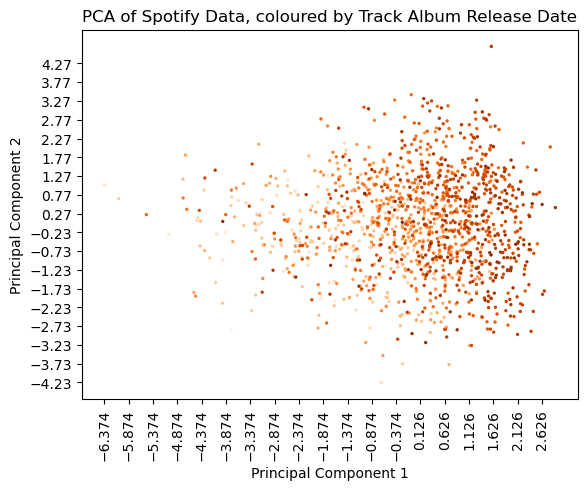

In [12]:
# TODO plot of PC1 vs PC2 coloured by interesting attribute
#plotting the first eigenvectors against the second. 



PC1 = X_std @ eigenvectors[:, 0]
PC2 = X_std @ eigenvectors[:, 1]

#extracting the track album relase date thing
date = df["track_album_release_date"]

plt.xticks(np.arange(min(PC1), max(PC1), 0.5), rotation=90)
plt.yticks(np.arange(min(PC2), max(PC2), 0.5))
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Spotify Data, coloured by Track Album Release Date")
plt.scatter(PC1, PC2, c=date, cmap="Oranges", s=2)
plt.show()

### Commentary
TODO _Describe any clusters, trends, or separations you see in PC space. What might drive them?_(Suggested word limit: 50 words)_

There is a trend that the higher both principle components are, the darker the colour, meaning the more recent the album release date is. There is a steady gradient as PC 1 increases where lower or negative PC not only has less dots, but also they are paler in appearance and so older albums. As PC 1 increases the number of points increases as well as the colour darkening meaning the albums are getting more recent.  This might suggest that older songs were a lot more simpler, and the newer songs tend to have a lot more of these varying sections. 